In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.3 MB/s eta 0:00:00


In [ ]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 49.7 MB/s eta 0:00:00


In [ ]:
# 필요 라이브러리 임포트
import os
import sys
sys.path.append('/content/drive/MyDrive/AI Health care 실습파일/MOLI/notebook')
from utils import AllTripletSelector, RandomNegativeTripletSelector

import random
import pickle
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

import time
from tqdm import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,             # AUROC
    average_precision_score,   # AUPR
    recall_score,              # Recall
    f1_score,                  # F1
    fbeta_score,               # F-beta
    precision_score,           # Precision (F1 계산 참고용)
    confusion_matrix           # TP/FP/TN/FN 확인용
)

In [ ]:
# ================================
# 0) 재현성(reproducibility) 설정
# ================================
def set_seed(seed: int = 11) -> None:
    """실험 결과를 최대한 재현 가능하게 만들기 위한 시드 고정 함수"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # GPU 사용 시 GPU용 난수 시드도 함께 고정
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

In [ ]:
# ===================================================
# 하이퍼파라미터 (Supplementary Table S3. MOLI_Complete_Pan_Drug)
# ===================================================

# Encoder
HIDDEN_DIM_EXPR = 32
HIDDEN_DIM_MUT  = 16
HIDDEN_DIM_CNA  = 256

# Drug Embedding
DRUG_TO_IDX = {
    'Cetuximab' : 0,
    'Afatinib'  : 1,
    'Erlotinib' : 2,
    'Gefitinib' : 3,
    'Lapatinib' : 4
}
IDX_TO_DRUG  = {v: k for k, v in DRUG_TO_IDX.items()}
NUM_DRUGS    = len(DRUG_TO_IDX)   # 5
DRUG_EMB_DIM = 8                  # 약물 임베딩 차원

# Classifier
Z_IN            = HIDDEN_DIM_EXPR + HIDDEN_DIM_MUT + HIDDEN_DIM_CNA  # 304
Z_TOTAL = Z_IN + DRUG_EMB_DIM     # 304 + 8 = 312

# Learning Rate
LR_EXPR = 0.001
LR_MUT  = 0.0001
LR_CNA  = 5e-5
LR_CLS  = 0.005

# Dropout
DROPOUT_EXPR = 0.5
DROPOUT_MUT  = 0.8
DROPOUT_CNA  = 0.5
DROPOUT_CLS  = 0.3

# 학습 설정
WEIGHT_DECAY = 0.0001
BATCH_SIZE   = 16
GAMMA        = 0.5
MARGIN       = 1.5
EPOCHS       = 20
FOLDS        = 5   # 추후 Cross Validation 구현 시 사용


print("📋 하이퍼파라미터 (Table S3 MOLI_Complete_Pan_Drug 기준)")
print(f"  Encoder hidden : expr={HIDDEN_DIM_EXPR} / mut={HIDDEN_DIM_MUT} / cna={HIDDEN_DIM_CNA}")
print(f"  Z_IN           : {Z_IN}  (encoder concat)")
print(f"  Drug Embedding : {NUM_DRUGS}약물 × {DRUG_EMB_DIM}차원")
print(f"  Z_TOTAL        : {Z_TOTAL}  (Z_IN + drug_emb)")
print(f"  LR             : expr={LR_EXPR} / mut={LR_MUT} / cna={LR_CNA} / cls={LR_CLS}")
print(f"  Dropout        : expr={DROPOUT_EXPR} / mut={DROPOUT_MUT} / cna={DROPOUT_CNA} / cls={DROPOUT_CLS}")
print(f"  weight_decay   : {WEIGHT_DECAY} (classifier only)")
print(f"  batch={BATCH_SIZE} / gamma={GAMMA} / margin={MARGIN} / epochs={EPOCHS}")

📋 하이퍼파라미터 (Table S3 MOLI_Complete_Pan_Drug 기준)
  Encoder hidden : expr=32 / mut=16 / cna=256
  Z_IN           : 304  (encoder concat)
  Drug Embedding : 5약물 × 8차원
  Z_TOTAL        : 312  (Z_IN + drug_emb)
  LR             : expr=0.001 / mut=0.0001 / cna=5e-05 / cls=0.005
  Dropout        : expr=0.5 / mut=0.8 / cna=0.5 / cls=0.3
  weight_decay   : 0.0001 (classifier only)
  batch=16 / gamma=0.5 / margin=1.5 / epochs=20


In [ ]:
# ===================================================
# 1) 데이터 로드
# ===================================================

BASE_DIR = "/content/drive/MyDrive/AI Health care 실습파일/MOLI"
save_dir = os.path.join(BASE_DIR, "preprocessed_EGFRi_v2")

# Train
X_train_expr = np.load(f"{save_dir}/X_train_expr.npy")
X_train_mut  = np.load(f"{save_dir}/X_train_mut.npy")
X_train_cna  = np.load(f"{save_dir}/X_train_cna.npy")
drug_id_train = np.load(f"{save_dir}/drug_id_train.npy")
y_train      = np.load(f"{save_dir}/y_train.npy")

# Val (PDX)
X_val_expr   = np.load(f"{save_dir}/X_val_expr.npy")
X_val_mut    = np.load(f"{save_dir}/X_val_mut.npy")
X_val_cna    = np.load(f"{save_dir}/X_val_cna.npy")
drug_id_val  = np.load(f"{save_dir}/drug_id_val.npy")
y_val        = np.load(f"{save_dir}/y_val.npy")

# Val (TCGA)
X_tcga_expr  = np.load(f"{save_dir}/X_tcga_expr.npy")
X_tcga_mut   = np.load(f"{save_dir}/X_tcga_mut.npy")
X_tcga_cna   = np.load(f"{save_dir}/X_tcga_cna.npy")
drug_id_tcga = np.load(f"{save_dir}/drug_id_tcga.npy")
y_tcga       = np.load(f"{save_dir}/y_tcga.npy")

# 입력 차원
INPUT_DIM_EXPR = X_train_expr.shape[1]  # 18232
INPUT_DIM_MUT  = X_train_mut.shape[1]   # 14447
INPUT_DIM_CNA  = X_train_cna.shape[1]   # 20503

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅ 데이터 로드 완료")
print(f"  Train: {X_train_expr.shape[0]}샘플 | R:{int((y_train==0).sum())} S:{int((y_train==1).sum())}")
print(f"  PDX  : {X_val_expr.shape[0]}샘플   | R:{int((y_val==0).sum())} S:{int((y_val==1).sum())}")
print(f"  TCGA : {X_tcga_expr.shape[0]}샘플  | R:{int((y_tcga==0).sum())} S:{int((y_tcga==1).sum())}")
print(f"\n📐 입력 차원:")
print(f"  Expression : {INPUT_DIM_EXPR:,}")
print(f"  Mutation   : {INPUT_DIM_MUT:,}")
print(f"  CNA        : {INPUT_DIM_CNA:,}")
print(f"\n💊 Drug ID 확인:")
print(f"  Train drug_id : {drug_id_train.shape} dtype={drug_id_train.dtype}")
print(f"  Val   drug_id : {drug_id_val.shape}   dtype={drug_id_val.dtype}")
print(f"  TCGA  drug_id : {drug_id_tcga.shape}  dtype={drug_id_tcga.dtype}")
print(f"  매핑: {IDX_TO_DRUG}")
print(f"\n🖥️  장치: {device}")

✅ 데이터 로드 완료
  Train: 3258샘플 | R:2747 S:511
  PDX  : 81샘플   | R:73 S:8
  TCGA : 15샘플  | R:8 S:7

📐 입력 차원:
  Expression : 16,307
  Mutation   : 14,447
  CNA        : 20,503

💊 Drug ID 확인:
  Train drug_id : (3258,) dtype=int64
  Val   drug_id : (81,)   dtype=int64
  TCGA  drug_id : (15,)  dtype=int64
  매핑: {0: 'Cetuximab', 1: 'Afatinib', 2: 'Erlotinib', 3: 'Gefitinib', 4: 'Lapatinib'}

🖥️  장치: cuda


In [ ]:
# 오믹스 데이터셋 클래스 생성
class OmicsDataset(Dataset):
    """
    3가지 Omics 데이터를 하나의 Dataset으로 묶는 클래스
    논문 Figure 1 입력 구조 구현
    """
    def __init__(self, expr, mut, cna, drug_ids, labels):
        self.expr     = torch.FloatTensor(expr)
        self.mut      = torch.FloatTensor(mut)
        self.cna      = torch.FloatTensor(cna)
        self.drug_ids = torch.LongTensor(drug_ids)   # ← Drug ID 추가
        self.labels   = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.expr[idx],
            self.mut[idx],
            self.cna[idx],
            self.drug_ids[idx],   # ← Drug ID 추가
            self.labels[idx]
        )

In [ ]:
# ===================================================
# 2) Dataset + DataLoader
# ===================================================

# 2-1) Dataset 생성
train_dataset = OmicsDataset(X_train_expr, X_train_mut, X_train_cna, drug_id_train, y_train)
val_dataset   = OmicsDataset(X_val_expr,   X_val_mut,   X_val_cna,   drug_id_val,   y_val)
tcga_dataset  = OmicsDataset(X_tcga_expr,  X_tcga_mut,  X_tcga_cna,  drug_id_tcga,  y_tcga)

# 2-2) Oversampling (Train만 적용)
class_counts   = np.bincount(y_train.astype(int))
class_weights  = 1.0 / class_counts
sample_weights = torch.FloatTensor([class_weights[int(y)] for y in y_train])
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

print(f"클래스 분포 - R:{class_counts[0]} / S:{class_counts[1]}")
print(f"클래스 가중치 - R:{class_weights[0]:.4f} / S:{class_weights[1]:.4f}")

# 2-3) DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    sampler    = sampler,
    drop_last  = True    # BatchNorm1d: 배치 크기 1 방지
)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False)
tcga_loader = DataLoader(tcga_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2-4) 확인
expr_b, mut_b, cna_b, drug_b, label_b = next(iter(train_loader))
print(f"\nTrain: {len(train_dataset)}샘플 / {len(train_loader)}배치")
print(f"PDX  : {len(val_dataset)}샘플")
print(f"TCGA : {len(tcga_dataset)}샘플")
print(f"\n배치 shape:")
print(f"  expr    : {tuple(expr_b.shape)}")
print(f"  mut     : {tuple(mut_b.shape)}")
print(f"  cna     : {tuple(cna_b.shape)}")
print(f"  drug_id : {tuple(drug_b.shape)}  dtype={drug_b.dtype}  ← LongTensor")
print(f"  label   : {tuple(label_b.shape)}")

# 2-5) Oversampling 검증
labels_sampled = []
for *_, lbl in train_loader:
    labels_sampled.extend(lbl.numpy())
labels_sampled = np.array(labels_sampled)
print(f"\n✅ Oversampling 후 분포:")
print(f"  R(0): {int((labels_sampled==0).sum())} ({(labels_sampled==0).mean()*100:.1f}%)")
print(f"  S(1): {int((labels_sampled==1).sum())} ({(labels_sampled==1).mean()*100:.1f}%)")

클래스 분포 - R:2747 / S:511
클래스 가중치 - R:0.0004 / S:0.0020

Train: 3258샘플 / 203배치
PDX  : 81샘플
TCGA : 15샘플

배치 shape:
  expr    : (16, 16307)
  mut     : (16, 14447)
  cna     : (16, 20503)
  drug_id : (16,)  dtype=torch.int64  ← LongTensor
  label   : (16,)

✅ Oversampling 후 분포:
  R(0): 1604 (49.4%)
  S(1): 1644 (50.6%)


In [ ]:
# ===================================================
# 3) 모델 정의
# ===================================================

# 3-1) Encoder
class OmicsEncoder(nn.Module):
    """Linear → BatchNorm → ReLU → Dropout"""
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.encoder(x)


# 3-2) Classifier
class Classifier(nn.Module):
    """Linear → Dropout → Sigmoid"""
    def __init__(self, z_total, dropout):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_total, 1),
            nn.Dropout(dropout),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.fc(x).squeeze(1)   # (N,1) → (N,)


# 3-3) MOLI + Drug Embedding
class MOLI(nn.Module):
    """
    Expression  → Encoder_E ──┐
    Mutation    → Encoder_M ──┼→ Concat(304) ──┐
    CNA         → Encoder_C ──┘                ├→ L2 Norm → Classifier → R/S
    Drug ID     → Embedding(8) ────────────────┘
    """
    def __init__(self, input_dim_expr, input_dim_mut, input_dim_cna):
        super().__init__()
        self.expr_encoder   = OmicsEncoder(input_dim_expr, HIDDEN_DIM_EXPR, DROPOUT_EXPR)
        self.mut_encoder    = OmicsEncoder(input_dim_mut,  HIDDEN_DIM_MUT,  DROPOUT_MUT)
        self.cna_encoder    = OmicsEncoder(input_dim_cna,  HIDDEN_DIM_CNA,  DROPOUT_CNA)
        self.drug_embedding = nn.Embedding(NUM_DRUGS, DRUG_EMB_DIM)
        self.classifier     = Classifier(Z_TOTAL, DROPOUT_CLS)

    def encode(self, expr, mut, cna, drug_id):
        z_expr = self.expr_encoder(expr)          # (N, 32)
        z_mut  = self.mut_encoder(mut)            # (N, 16)
        z_cna  = self.cna_encoder(cna)            # (N, 256)
        z_drug = self.drug_embedding(drug_id)     # (N, 8)

        z = torch.cat([z_expr, z_mut, z_cna, z_drug], dim=1)  # (N, 312)
        z = F.normalize(z, p=2, dim=1)            # 샘플 방향으로 정규화
        return z

    def forward(self, expr, mut, cna, drug_id):
        """평가/추론용: 예측값만 반환"""
        z = self.encode(expr, mut, cna, drug_id)
        return self.classifier(z)                 # (N,)

    def forward_train(self, expr, mut, cna, drug_id):
        """학습용: embedding + 예측값 동시 반환 (encode 1번만 실행)"""
        z    = self.encode(expr, mut, cna, drug_id)
        pred = self.classifier(z)
        return pred, z


# 3-4) 모델 생성
model = MOLI(
    input_dim_expr = INPUT_DIM_EXPR,
    input_dim_mut  = INPUT_DIM_MUT,
    input_dim_cna  = INPUT_DIM_CNA
).to(device)

# 3-5) Optimizer (원본: Encoder weight_decay 없음, Classifier만 있음)
solverE   = optim.Adagrad(model.expr_encoder.parameters(), lr=LR_EXPR)
solverM   = optim.Adagrad(model.mut_encoder.parameters(), lr=LR_MUT)
solverC   = optim.Adagrad(model.cna_encoder.parameters(), lr=LR_CNA)
solverCLS = optim.Adagrad(model.classifier.parameters(), lr=LR_CLS, weight_decay=WEIGHT_DECAY)
# Drug Embedding은 Classifier optimizer에 포함
solverDRUG = optim.Adagrad(model.drug_embedding.parameters(), lr=LR_CLS)

# 3-6) 확인
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ 모델 생성 완료")
print(f"  구조: omics → FC(32/16/256) → concat(304)")
print(f"        drug  → Embedding(5×8=40 params)")
print(f"        total concat: {Z_TOTAL} → classifier")
print(f"  전체 파라미터: {total_params:,}")

with torch.no_grad():
    z   = model.encode(
        expr_b.to(device), mut_b.to(device),
        cna_b.to(device),  drug_b.to(device)
    )
    out = model(
        expr_b.to(device), mut_b.to(device),
        cna_b.to(device),  drug_b.to(device)
    )
print(f"\nshape 확인:")
print(f"  encode 출력 z : {tuple(z.shape)}  ← (N, {Z_TOTAL})")
print(f"  forward 출력  : {tuple(out.shape)} ← (N,)")
print(f"  범위: [{out.min():.3f}, {out.max():.3f}]  ← (0, 1) 정상")

✅ 모델 생성 완료
  구조: omics → FC(32/16/256) → concat(304)
        drug  → Embedding(5×8=40 params)
        total concat: 312 → classifier
  전체 파라미터: 6,003,009

shape 확인:
  encode 출력 z : (16, 312)  ← (N, 312)
  forward 출력  : (16,) ← (N,)
  범위: [0.491, 0.523]  ← (0, 1) 정상


In [ ]:
# ===================================================
# 4) 손실 함수 정의
# ===================================================
# PyTorch 내장 TripletMarginLoss 사용

trip_criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)
bce_loss       = nn.BCELoss()

print("✅ Loss 함수 준비 완료")
print(f"  TripletMarginLoss : margin={MARGIN}, p=2 (원본과 동일)")
print(f"  BCELoss           : ✅")
print(f"  γ (gamma)         : {GAMMA}")

✅ Loss 함수 준비 완료
  TripletMarginLoss : margin=1.5, p=2 (원본과 동일)
  BCELoss           : ✅
  γ (gamma)         : 0.5


In [ ]:
# ===================================================
# 5) Triplets Selector
# ===================================================

# 학습 시 RandomNegative, 평가 시 AllTriplets
triplet_selector_train = RandomNegativeTripletSelector(margin=MARGIN)
triplet_selector_eval  = AllTripletSelector()

# TripletMarginLoss: reduction='mean'
trip_criterion = nn.TripletMarginLoss(margin=MARGIN, p=2, reduction='mean')
bce_loss       = nn.BCELoss()

# 동작 확인
dummy_emb    = torch.randn(16, Z_TOTAL).cpu()
dummy_labels = torch.tensor([1,0,1,0,1,0,1,0,
                              1,0,1,0,1,0,1,0], dtype=torch.float32)

trips_train = triplet_selector_train.get_triplets(dummy_emb, dummy_labels)
trips_eval  = triplet_selector_eval.get_triplets(dummy_emb, dummy_labels)

print(f"✅ 원본 utils.py TripletSelector 로드 완료")
print(f"  학습: RandomNegativeTripletSelector")
print(f"    → 각 (A,P) 쌍에 대해 loss>0인 N 중 랜덤 선택")
print(f"    → triplet 수: {len(trips_train)}개")
print(f"  평가: AllTripletSelector")
print(f"    → 모든 조합: {len(trips_eval)}개")
print(f"\n  원본 코드 방식:")
print(f"    학습: RandomNegative (Hard Triplet의 완화 버전)")
print(f"    평가: All Triplets")

✅ 원본 utils.py TripletSelector 로드 완료
  학습: RandomNegativeTripletSelector
    → 각 (A,P) 쌍에 대해 loss>0인 N 중 랜덤 선택
    → triplet 수: 50개
  평가: AllTripletSelector
    → 모든 조합: 448개

  원본 코드 방식:
    학습: RandomNegative (Hard Triplet의 완화 버전)
    평가: All Triplets


In [ ]:
## ===================================================
# 6) 평가 함수
# ===================================================

def evaluate(model, loader, device, dataset_name=""):
    """
    전체 + 약물별 평가 지표 계산
    """
    model.eval()
    all_probs   = []
    all_labels  = []
    all_drug_ids = []

    with torch.no_grad():
        for expr, mut, cna, drug_id, label in loader:
            out = model(
                expr.to(device), mut.to(device),
                cna.to(device),  drug_id.to(device)
            )
            all_probs.extend(out.cpu().numpy())
            all_labels.extend(label.numpy())
            all_drug_ids.extend(drug_id.numpy())

    y_prob  = np.array(all_probs)
    y_true  = np.array(all_labels).astype(int)
    drug_ids = np.array(all_drug_ids)
    y_pred  = (y_prob >= 0.5).astype(int)

    def calc_metrics(y_t, y_p, y_pr, beta=2):
        if len(np.unique(y_t)) < 2:
            return None   # 단일 클래스 → AUROC 계산 불가
        return {
            'AUROC'    : roc_auc_score(y_t, y_pr),
            'AUPR'     : average_precision_score(y_t, y_pr),
            'Recall'   : recall_score(y_t, y_p, zero_division=0),
            'Precision': precision_score(y_t, y_p, zero_division=0),
            'F1'       : f1_score(y_t, y_p, zero_division=0),
            f'F{beta}'  : fbeta_score(y_t, y_p, beta=beta, zero_division=0),
        }

    results = {}

    # 전체 평가
    overall = calc_metrics(y_true, y_pred, y_prob)
    if overall:
        results['overall'] = overall

    # 약물별 평가
    for drug_idx, drug_name in IDX_TO_DRUG.items():
        mask = (drug_ids == drug_idx)
        if mask.sum() == 0:
            continue
        m = calc_metrics(y_true[mask], y_pred[mask], y_prob[mask])
        if m:
            results[drug_name] = m

    # 출력
    if dataset_name:
        print(f"\n{'='*50}")
        print(f"📊 {dataset_name} 평가 결과")
        print(f"{'='*50}")
        for key, m in results.items():
            tag = "전체" if key == 'overall' else f"💊 {key}"
            print(f"  [{tag}]")
            for metric, val in m.items():
                print(f"    {metric:10s}: {val:.4f}")

    return results


print("✅ 평가 함수 준비 완료")
print(f"  평가 지표: AUROC, AUPR, Recall, Precision, F1, F2")
print(f"  평가 방식: 전체 통합 + 약물별 개별")

✅ 평가 함수 준비 완료
  평가 지표: AUROC, AUPR, Recall, Precision, F1, F2
  평가 방식: 전체 통합 + 약물별 개별


In [ ]:
# ===================================================
# 7) 학습 루프
# ===================================================

best_pdx_auroc   = 0.0
best_model_state = None
history = {
    'train_loss' : [],
    'train_auroc': [],
    'pdx_auroc'  : [],
    'tcga_auroc' : []
}

print(f"🚀 학습 시작 | epochs={EPOCHS} | batch={BATCH_SIZE} | device={device}")
print("=" * 60)

for epoch in range(EPOCHS):

    # ===================================================
    # 7-1) 한 epoch 학습
    # ===================================================
    model.train()
    epoch_loss  = 0.0
    epoch_auroc = []
    n_batches   = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:>2}/{EPOCHS} [Train]",
                leave=False, ncols=90)

    for expr, mut, cna, drug_id, target in pbar:

        if torch.mean(target) == 0. or torch.mean(target) == 1.:
            continue

        expr    = expr.to(device)
        mut     = mut.to(device)
        cna     = cna.to(device)
        drug_id = drug_id.to(device)
        target  = target.to(device)

        pred, embeddings = model.forward_train(expr, mut, cna, drug_id)

        # 원본 방식: CPU에서 triplet 선택 후 GPU로
        triplets = triplet_selector_train.get_triplets(
            embeddings.detach().cpu(), target.cpu()
        )

        if len(triplets) == 0:
            continue

        triplets = triplets.to(device)

        trip_loss = trip_criterion(
            embeddings[triplets[:, 0]],
            embeddings[triplets[:, 1]],
            embeddings[triplets[:, 2]]
        )
        bce  = bce_loss(pred, target)
        loss = GAMMA * trip_loss + bce

        for opt in [solverE, solverM, solverC, solverCLS, solverDRUG]:
            opt.zero_grad()
        loss.backward()
        for opt in [solverE, solverM, solverC, solverCLS, solverDRUG]:
            opt.step()

        epoch_loss += loss.item()
        n_batches  += 1

        y_t = target.cpu().numpy().astype(int)
        y_p = pred.detach().cpu().numpy()
        if len(np.unique(y_t)) == 2:
            epoch_auroc.append(roc_auc_score(y_t, y_p))

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # ===================================================
    # 7-2) epoch 검증
    # ===================================================
    pdx_results  = evaluate(model, val_loader,  device)
    tcga_results = evaluate(model, tcga_loader, device)

    pdx_auroc  = pdx_results.get('overall',  {}).get('AUROC', 0.0)
    tcga_auroc = tcga_results.get('overall', {}).get('AUROC', 0.0)

    # ===================================================
    # 7-3) Loss와 AUROC 기록
    # ===================================================
    avg_loss  = epoch_loss / max(n_batches, 1)
    avg_auroc = np.mean(epoch_auroc) if epoch_auroc else 0.0

    history['train_loss'].append(avg_loss)
    history['train_auroc'].append(avg_auroc)
    history['pdx_auroc'].append(pdx_auroc)
    history['tcga_auroc'].append(tcga_auroc)

    # ===================================================
    # 7-4) 지금까지 최고 성능이면 모델 저장
    # ===================================================
    is_best = pdx_auroc > best_pdx_auroc
    if is_best:
        best_pdx_auroc   = pdx_auroc
        best_model_state = deepcopy(model.state_dict())

    print(f"Epoch {epoch+1:>2}/{EPOCHS} | "
          f"loss={avg_loss:.4f} | train_auc={avg_auroc:.4f} | "
          f"PDX={pdx_auroc:.4f} | TCGA={tcga_auroc:.4f}"
          + (" ⭐ best" if is_best else ""))

# ===================================================
# 7-5) 반복 종료 → Best 모델로 최종 평가
# ===================================================
print("=" * 60)
print(f"\n🏆 Best PDX AUROC: {best_pdx_auroc:.4f}")
model.load_state_dict(best_model_state)
print("✅ Best 모델 로드 완료 → 최종 평가")
_ = evaluate(model, val_loader,  device, dataset_name="PDX  (Best)")
_ = evaluate(model, tcga_loader, device, dataset_name="TCGA (Best)")

🚀 학습 시작 | epochs=20 | batch=16 | device=cuda


Epoch  1/20 | loss=1.4046 | train_auc=0.7194 | PDX=0.6712 | TCGA=0.3571 ⭐ best


Epoch  2/20 | loss=1.3731 | train_auc=0.7580 | PDX=0.6901 | TCGA=0.3750 ⭐ best


Epoch  3/20 | loss=1.3416 | train_auc=0.7825 | PDX=0.6798 | TCGA=0.3750


Epoch  4/20 | loss=1.3242 | train_auc=0.7921 | PDX=0.6781 | TCGA=0.3750


...

Epoch 16/20 | loss=1.2210 | train_auc=0.8462 | PDX=0.7003 | TCGA=0.5000


Epoch 17/20 | loss=1.2033 | train_auc=0.8663 | PDX=0.7055 | TCGA=0.4643


Epoch 18/20 | loss=1.1999 | train_auc=0.8696 | PDX=0.7021 | TCGA=0.4643


Epoch 19/20 | loss=1.2045 | train_auc=0.8628 | PDX=0.7072 | TCGA=0.4821 ⭐ best


Epoch 20/20 | loss=1.1954 | train_auc=0.8668 | PDX=0.7175 | TCGA=0.4821 ⭐ best

🏆 Best PDX AUROC: 0.7175
✅ Best 모델 로드 완료 → 최종 평가

📊 PDX  (Best) 평가 결과
  [전체]
    AUROC     : 0.7175
    AUPR      : 0.4157
    Recall    : 0.5000
    Precision : 0.1600
    F1        : 0.2424
    F2        : 0.3509
  [💊 Cetuximab]
    AUROC     : 0.6909
    AUPR      : 0.4185
    Recall    : 0.4000
    Precision : 0.1176
    F1        : 0.1818
    F2        : 0.2703
  [💊 Erlotinib]
    AUROC     : 0.7037
    AUPR      : 0.5588
    Recall    : 0.6667
    Precision : 0.2500
    F1        : 0.3636
    F2        : 0.5000

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.4821
    AUPR      : 0.4566
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Cetuximab]
    AUROC     : 0.2917
    AUPR      : 0.5161
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Erlotinib]
    AUROC     : 0.5000
    AUPR      : 0.5000
    Recall    :

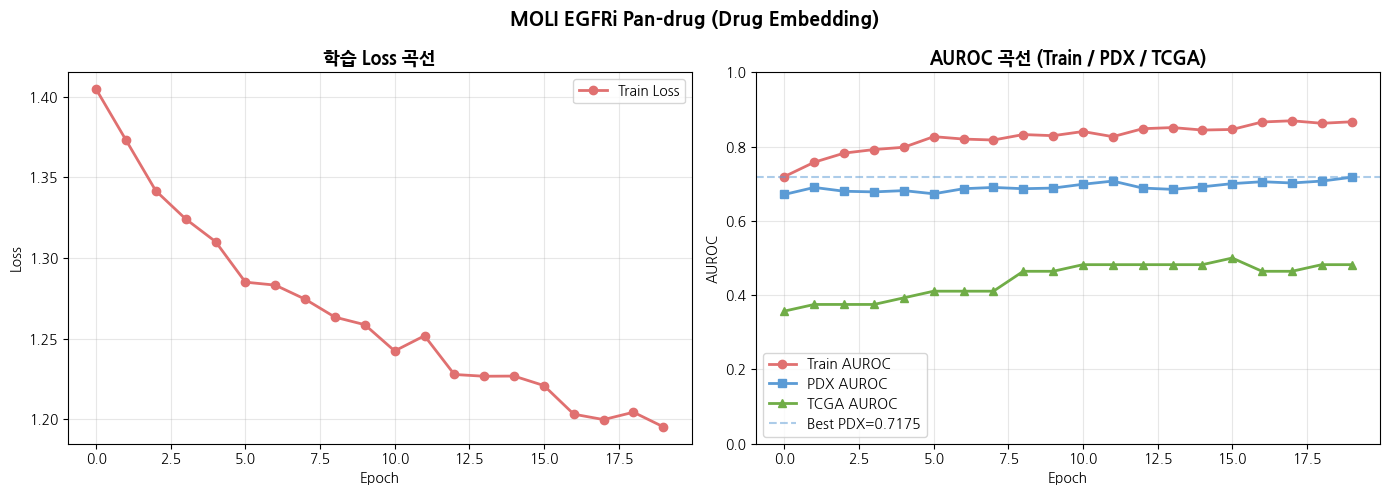

✅ 학습 곡선 저장 완료


In [ ]:
# ===================================================
# 8) 학습 곡선 시각화
# ===================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], '-o', color='#E07070', label='Train Loss', linewidth=2)
axes[0].set_title('학습 Loss 곡선', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUROC
axes[1].plot(history['train_auroc'], '-o', color='#E07070', label='Train AUROC', linewidth=2)
axes[1].plot(history['pdx_auroc'],   '-s', color='#5B9BD5', label='PDX AUROC',   linewidth=2)
axes[1].plot(history['tcga_auroc'],  '-^', color='#70AD47', label='TCGA AUROC',  linewidth=2)
axes[1].axhline(y=best_pdx_auroc, color='#5B9BD5', linestyle='--', alpha=0.5,
                label=f'Best PDX={best_pdx_auroc:.4f}')
axes[1].set_title('AUROC 곡선 (Train / PDX / TCGA)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('MOLI EGFRi Pan-drug (Drug Embedding)', fontsize=14, fontweight='bold')
plt.tight_layout()

output_dir = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/outputs/EGFRi"
plt.savefig(f'{output_dir}/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 학습 곡선 저장 완료")

In [ ]:
# Best 기준: PDX AUROC + AUPR 조합 점수
def combined_score(metrics, w_auroc=0.7, w_aupr=0.3):
    """
    AUROC와 AUPR 가중 조합
    클래스 불균형 시 AUPR이 더 신뢰할 수 있음
    """
    auroc = metrics.get('AUROC', 0.0)
    aupr  = metrics.get('AUPR',  0.0)
    return w_auroc * auroc + w_aupr * aupr

In [ ]:
# ===================================================
# 7-b) 학습 루프 (방향 2: PDX Cetuximab 기준으로 평가)
# ===================================================

best_score       = 0.0
best_model_state = None
history = {
    'train_loss'        : [],
    'train_auroc'       : [],
    'pdx_overall'       : [],
    'pdx_cetuximab'     : [],
    'pdx_erlotinib'     : [],
    'tcga_overall'      : [],
}

print(f"🚀 학습 시작 | epochs={EPOCHS} | batch={BATCH_SIZE} | device={device}")
print(f"   Best 기준: PDX Cetuximab AUROC×0.7 + AUPR×0.3 (논문 동일 조건)")
print("=" * 65)

for epoch in range(EPOCHS):

    # 학습
    model.train()
    epoch_loss  = 0.0
    epoch_auroc = []
    n_batches   = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:>2}/{EPOCHS} [Train]",
                leave=False, ncols=90)

    for expr, mut, cna, drug_id, target in pbar:

        if torch.mean(target) == 0. or torch.mean(target) == 1.:
            continue

        expr    = expr.to(device)
        mut     = mut.to(device)
        cna     = cna.to(device)
        drug_id = drug_id.to(device)
        target  = target.to(device)

        pred, embeddings = model.forward_train(expr, mut, cna, drug_id)

        triplets = get_hard_triplets(embeddings, target)
        if triplets is None:
            continue

        trip_loss = trip_criterion(
            embeddings[triplets[:, 0]],
            embeddings[triplets[:, 1]],
            embeddings[triplets[:, 2]]
        )
        bce  = bce_loss(pred, target)
        loss = GAMMA * trip_loss + bce

        for opt in [solverE, solverM, solverC, solverCLS, solverDRUG]:
            opt.zero_grad()
        loss.backward()
        for opt in [solverE, solverM, solverC, solverCLS, solverDRUG]:
            opt.step()

        epoch_loss += loss.item()
        n_batches  += 1

        y_t = target.cpu().numpy().astype(int)
        y_p = pred.detach().cpu().numpy()
        if len(np.unique(y_t)) == 2:
            epoch_auroc.append(roc_auc_score(y_t, y_p))

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # 검증
    pdx_results  = evaluate(model, val_loader,  device)
    tcga_results = evaluate(model, tcga_loader, device)

    # 약물별 분리 추출
    pdx_cetu_m = pdx_results.get('Cetuximab', {})
    pdx_erlo_m = pdx_results.get('Erlotinib', {})
    pdx_all_m  = pdx_results.get('overall',   {})
    tcga_all_m = tcga_results.get('overall',  {})

    pdx_cetu_auroc = pdx_cetu_m.get('AUROC', 0.0)
    pdx_erlo_auroc = pdx_erlo_m.get('AUROC', 0.0)
    pdx_all_auroc  = pdx_all_m.get('AUROC',  0.0)
    tcga_auroc     = tcga_all_m.get('AUROC',  0.0)

    # 기록
    avg_loss  = epoch_loss / max(n_batches, 1)
    avg_auroc = np.mean(epoch_auroc) if epoch_auroc else 0.0

    history['train_loss'].append(avg_loss)
    history['train_auroc'].append(avg_auroc)
    history['pdx_overall'].append(pdx_all_auroc)
    history['pdx_cetuximab'].append(pdx_cetu_auroc)
    history['pdx_erlotinib'].append(pdx_erlo_auroc)
    history['tcga_overall'].append(tcga_auroc)

    # Best 저장 (PDX Cetuximab 기준)
    cetu_score = combined_score(pdx_cetu_m)   # AUROC×0.7 + AUPR×0.3
    is_best    = cetu_score > best_score
    if is_best:
        best_score       = cetu_score
        best_model_state = deepcopy(model.state_dict())

    print(f"Epoch {epoch+1:>2}/{EPOCHS} | "
          f"loss={avg_loss:.4f} | train={avg_auroc:.4f} | "
          f"PDX_Cetu={pdx_cetu_auroc:.4f} | "
          f"PDX_Erlo={pdx_erlo_auroc:.4f} | "
          f"TCGA={tcga_auroc:.4f}"
          + (" ⭐" if is_best else ""))

# Best 모델 최종 평가
print("=" * 65)
print(f"\n🏆 Best score (PDX Cetuximab 기준): {best_score:.4f}")
model.load_state_dict(best_model_state)
print("✅ Best 모델 로드 → 최종 평가")
_ = evaluate(model, val_loader,  device, dataset_name="PDX  (Best)")
_ = evaluate(model, tcga_loader, device, dataset_name="TCGA (Best)")

🚀 학습 시작 | epochs=20 | batch=16 | device=cuda
   Best 기준: PDX Cetuximab AUROC×0.7 + AUPR×0.3 (논문 동일 조건)


Epoch  1/20 | loss=1.2045 | train=0.8667 | PDX_Cetu=0.6982 | PDX_Erlo=0.7222 | TCGA=0.4821 ⭐


Epoch  2/20 | loss=1.2100 | train=0.8523 | PDX_Cetu=0.7091 | PDX_Erlo=0.7407 | TCGA=0.4821 ⭐


Epoch  3/20 | loss=1.1972 | train=0.8655 | PDX_Cetu=0.6945 | PDX_Erlo=0.7407 | TCGA=0.4821


Epoch  4/20 | loss=1.2076 | train=0.8543 | PDX_Cetu=0.6909 | PDX_Erlo=0.7407 | TCGA=0.4821


...

Epoch 16/20 | loss=1.1642 | train=0.8702 | PDX_Cetu=0.6945 | PDX_Erlo=0.8333 | TCGA=0.4821


Epoch 17/20 | loss=1.1659 | train=0.8717 | PDX_Cetu=0.6836 | PDX_Erlo=0.8519 | TCGA=0.4821


Epoch 18/20 | loss=1.1617 | train=0.8783 | PDX_Cetu=0.6727 | PDX_Erlo=0.8333 | TCGA=0.4821


Epoch 19/20 | loss=1.1469 | train=0.8787 | PDX_Cetu=0.6873 | PDX_Erlo=0.8704 | TCGA=0.5000


Epoch 20/20 | loss=1.1474 | train=0.8874 | PDX_Cetu=0.6982 | PDX_Erlo=0.8519 | TCGA=0.5000

🏆 Best score (PDX Cetuximab 기준): 0.6316
✅ Best 모델 로드 → 최종 평가

📊 PDX  (Best) 평가 결과
  [전체]
    AUROC     : 0.7517
    AUPR      : 0.4305
    Recall    : 0.5000
    Precision : 0.1818
    F1        : 0.2667
    F2        : 0.3704
  [💊 Cetuximab]
    AUROC     : 0.7200
    AUPR      : 0.4252
    Recall    : 0.4000
    Precision : 0.1333
    F1        : 0.2000
    F2        : 0.2857
  [💊 Erlotinib]
    AUROC     : 0.7593
    AUPR      : 0.5714
    Recall    : 0.6667
    Precision : 0.2857
    F1        : 0.4000
    F2        : 0.5263

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.5000
    AUPR      : 0.4644
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Cetuximab]
    AUROC     : 0.2917
    AUPR      : 0.5161
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Erlotinib]
    AUROC     : 0.5000
    AUPR      

/tmp/ipykernel_2275/674987663.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-^" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1].plot(history['pdx_erlotinib'],'-^', color='#9DC3E6',


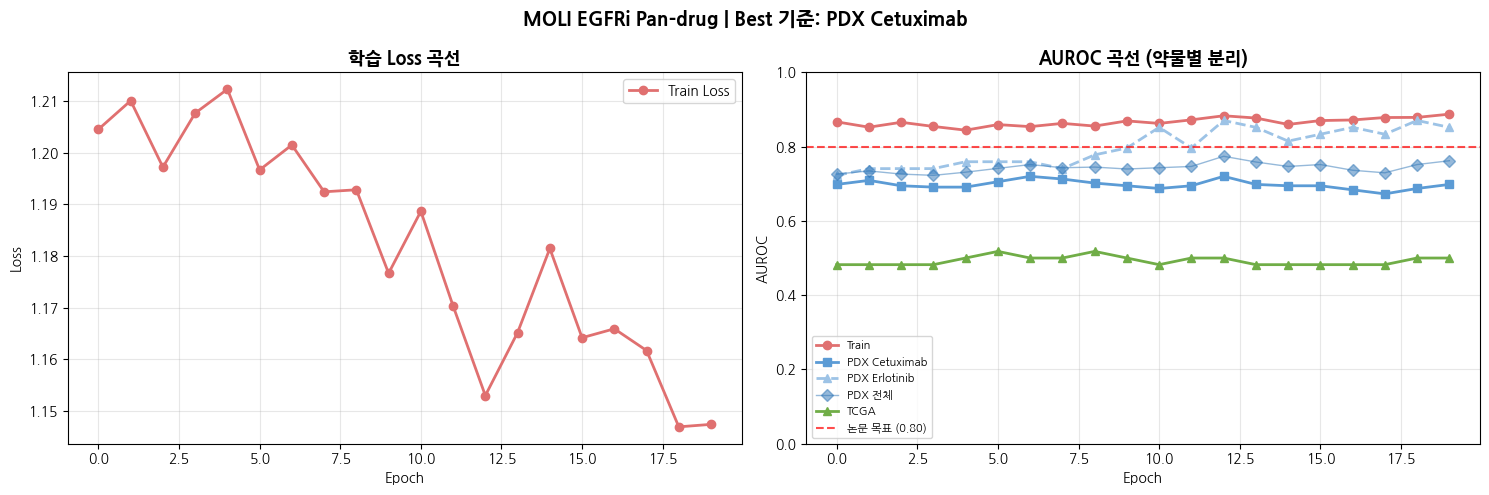

In [ ]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_loss'], '-o', color='#E07070',
             label='Train Loss', linewidth=2)
axes[0].set_title('학습 Loss 곡선', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_auroc'],   '-o', color='#E07070',
             label='Train',            linewidth=2)
axes[1].plot(history['pdx_cetuximab'],'-s', color='#5B9BD5',
             label='PDX Cetuximab',    linewidth=2)
axes[1].plot(history['pdx_erlotinib'],'-^', color='#9DC3E6',
             label='PDX Erlotinib',    linewidth=2, linestyle='--')
axes[1].plot(history['pdx_overall'],  '-D', color='#2E75B6',
             label='PDX 전체',         linewidth=1, alpha=0.5)
axes[1].plot(history['tcga_overall'], '-^', color='#70AD47',
             label='TCGA',             linewidth=2)
axes[1].axhline(y=0.80, color='red', linestyle='--', alpha=0.7,
                label='논문 목표 (0.80)')
axes[1].set_title('AUROC 곡선 (약물별 분리)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('MOLI EGFRi Pan-drug | Best 기준: PDX Cetuximab',
             fontsize=14, fontweight='bold')
plt.tight_layout()
output_dir = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/outputs/EGFRi"
plt.savefig(f'{output_dir}/training_curve_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ===================================================
# 학습 함수 정의_학습 기준 변경
# ===================================================

def train_one_epoch(model, loader, optimizers, device):
    """한 epoch 학습 → (avg_loss, avg_auroc) 반환"""
    model.train()
    epoch_loss  = 0.0
    epoch_auroc = []
    n_batches   = 0

    solverE, solverM, solverC, solverCLS, solverDRUG = optimizers

    for expr, mut, cna, drug_id, target in loader:

        if torch.mean(target) == 0. or torch.mean(target) == 1.:
            continue

        expr    = expr.to(device)
        mut     = mut.to(device)
        cna     = cna.to(device)
        drug_id = drug_id.to(device)
        target  = target.to(device)

        pred, embeddings = model.forward_train(expr, mut, cna, drug_id)

        # 원본 방식: CPU에서 triplet 선택 후 GPU로
        triplets = triplet_selector_train.get_triplets(
            embeddings.detach().cpu(), target.cpu()
        )

        if len(triplets) == 0:
            continue

        triplets = triplets.to(device)

        trip_loss = trip_criterion(
            embeddings[triplets[:, 0]],
            embeddings[triplets[:, 1]],
            embeddings[triplets[:, 2]]
        )
        bce  = bce_loss(pred, target)
        loss = GAMMA * trip_loss + bce

        for opt in optimizers:
            opt.zero_grad()
        loss.backward()
        for opt in optimizers:
            opt.step()

        epoch_loss += loss.item()
        n_batches  += 1

        y_t = target.cpu().numpy().astype(int)
        y_p = pred.detach().cpu().numpy()
        if len(np.unique(y_t)) == 2:
            epoch_auroc.append(roc_auc_score(y_t, y_p))

    avg_loss  = epoch_loss / max(n_batches, 1)
    avg_auroc = np.mean(epoch_auroc) if epoch_auroc else 0.0
    return avg_loss, avg_auroc


def make_model_and_optimizers(lr_expr, lr_mut, lr_cna, lr_cls, weight_decay):
    """모델 + 옵티마이저 생성 헬퍼"""
    m = MOLI(INPUT_DIM_EXPR, INPUT_DIM_MUT, INPUT_DIM_CNA).to(device)
    opts = (
        optim.Adagrad(m.expr_encoder.parameters(),   lr=lr_expr),
        optim.Adagrad(m.mut_encoder.parameters(),    lr=lr_mut),
        optim.Adagrad(m.cna_encoder.parameters(),    lr=lr_cna),
        optim.Adagrad(m.classifier.parameters(),     lr=lr_cls,
                      weight_decay=weight_decay),
        optim.Adagrad(m.drug_embedding.parameters(), lr=lr_cls),
    )
    return m, opts


print("✅ 학습 함수 준비 완료")

✅ 학습 함수 준비 완료


In [ ]:
# ===================================================
# 5-Fold CV + Early Stopping
# ===================================================

def run_cv(params, n_splits=5, max_epochs=50, patience=7, verbose=True):
    """
    5-Fold CV 실행
    params: dict (lr_expr, lr_mut, lr_cna, lr_cls, weight_decay, gamma, margin)

    Returns: fold별 best PDX score 리스트
    """
    lr_expr      = params['lr_expr']
    lr_mut       = params['lr_mut']
    lr_cna       = params['lr_cna']
    lr_cls       = params['lr_cls']
    weight_decay = params['weight_decay']
    gamma_val    = params['gamma']
    margin_val   = params['margin']

    # Trip/BCE loss는 파라미터에 따라 새로 생성
    trip_crit = nn.TripletMarginLoss(margin=margin_val, p=2)
    bce_crit  = nn.BCELoss()

    # 전체 Train 데이터 인덱스
    indices = np.arange(len(y_train))
    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    best_state_fold = []
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(indices, y_train.astype(int))):

        if verbose:
            print(f"\n  📂 Fold {fold+1}/{n_splits}")

        # Fold별 데이터셋
        fold_train = OmicsDataset(
            X_train_expr[tr_idx],  X_train_mut[tr_idx],
            X_train_cna[tr_idx],   drug_id_train[tr_idx],
            y_train[tr_idx]
        )
        fold_val = OmicsDataset(
            X_train_expr[val_idx], X_train_mut[val_idx],
            X_train_cna[val_idx],  drug_id_train[val_idx],
            y_train[val_idx]
        )

        # Oversampling (Fold Train만 적용)
        fold_class_counts  = np.bincount(y_train[tr_idx].astype(int))
        fold_class_weights = 1.0 / fold_class_counts
        fold_sample_w = torch.FloatTensor(
            [fold_class_weights[int(y)] for y in y_train[tr_idx]]
        )
        fold_sampler = WeightedRandomSampler(
            fold_sample_w, len(fold_sample_w), replacement=True
        )

        fold_train_loader = DataLoader(
            fold_train, batch_size=BATCH_SIZE,
            sampler=fold_sampler, drop_last=True
        )
        fold_val_loader = DataLoader(
            fold_val, batch_size=BATCH_SIZE, shuffle=False
        )

        # 모델 + Optimizer
        model_cv, optimizers_cv = make_model_and_optimizers(
            lr_expr, lr_mut, lr_cna, lr_cls, weight_decay
        )

        # Early Stopping 변수
        best_score    = 0.0
        best_state    = None
        patience_cnt  = 0

        for epoch in range(max_epochs):

            # 1) 학습
            avg_loss, avg_auroc = train_one_epoch(
                model_cv, fold_train_loader, optimizers_cv, device
            )

            # 2) 검증 (Fold Val = Train 일부)
            fold_val_results = evaluate(model_cv, fold_val_loader, device)
            fold_metrics     = fold_val_results.get('overall', {})
            score            = fold_metrics.get('AUROC', 0.0)

            # 3) Best 기준: AUROC + AUPR 조합 점수
            if score > best_score:
                best_score = score
                best_state = deepcopy(model_cv.state_dict())
                patience_cnt = 0
            else:
                patience_cnt += 1

            if verbose:
                auroc = fold_metrics.get('AUROC', 0.0)
                aupr  = fold_metrics.get('AUPR',  0.0)
                mark  = " ⭐" if patience_cnt == 0 else ""
                print(f"    Epoch {epoch+1:>2} | loss={avg_loss:.4f} | "
                      f"AUROC={auroc:.4f} AUPR={aupr:.4f} "
                      f"score={score:.4f}{mark} "
                      f"[patience {patience_cnt}/{patience}]")

            # 4) Early Stopping
            if patience_cnt >= patience:
                if verbose:
                    print(f"    ⏹ Early Stopping at epoch {epoch+1}")
                break

        best_state_fold.append(best_state)
        fold_scores.append(best_score)
        if verbose:
            print(f"  ✅ Fold {fold+1} Best score: {best_score:.4f}")

    return best_state_fold, fold_scores


# 기본 파라미터로 CV 실행
base_params = {
    'lr_expr'     : LR_EXPR,
    'lr_mut'      : LR_MUT,
    'lr_cna'      : LR_CNA,
    'lr_cls'      : LR_CLS,
    'weight_decay': WEIGHT_DECAY,
    'gamma'       : GAMMA,
    'margin'      : MARGIN,
}

print("🔁 5-Fold CV 시작 (기본 파라미터)")
print(f"   Early Stopping patience=7 | max_epochs=50")
print(f"   Best 기준: AUROC×0.7 + AUPR×0.3")
print("=" * 60)

best_state, cv_scores = run_cv(base_params, n_splits=5, max_epochs=50, patience=7)

print("\n" + "=" * 60)
print(f"📊 5-Fold CV 결과:")
for i, s in enumerate(cv_scores):
    print(f"  Fold {i+1}: {s:.4f}")
print(f"  평균: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

🔁 5-Fold CV 시작 (기본 파라미터)
   Early Stopping patience=7 | max_epochs=50
   Best 기준: AUROC×0.7 + AUPR×0.3

  📂 Fold 1/5
    Epoch  1 | loss=1.3972 | AUROC=0.8067 AUPR=0.4975 score=0.8067 ⭐ [patience 0/7]
    Epoch  2 | loss=1.3644 | AUROC=0.8171 AUPR=0.5138 score=0.8171 ⭐ [patience 0/7]
    Epoch  3 | loss=1.3363 | AUROC=0.8087 AUPR=0.5149 score=0.8087 [patience 1/7]
    Epoch  4 | loss=1.3357 | AUROC=0.8180 AUPR=0.5503 score=0.8180 ⭐ [patience 0/7]
    Epoch  5 | loss=1.3131 | AUROC=0.8188 AUPR=0.5472 score=0.8188 ⭐ [patience 0/7]
    Epoch  6 | loss=1.3022 | AUROC=0.8220 AUPR=0.5678 score=0.8220 ⭐ [patience 0/7]
    Epoch  7 | loss=1.2869 | AUROC=0.8236 AUPR=0.5724 score=0.8236 ⭐ [patience 0/7]
    Epoch  8 | loss=1.2893 | AUROC=0.8217 AUPR=0.5642 score=0.8217 [patience 1/7]
    Epoch  9 | loss=1.2654 | AUROC=0.8232 AUPR=0.5638 score=0.8232 [patience 2/7]
    Epoch 10 | loss=1.2603 | AUROC=0.8241 AUPR=0.5613 score=0.8241 ⭐ [patience 0/7]
    Epoch 11 | loss=1.2493 | AUROC=0.8269 AUPR=0.

In [ ]:
print("=" * 60)
cetu_aurocs = []

for i, state in enumerate(best_state):
    model.load_state_dict(state)

    print("\n✅ Best 모델 로드 완료 → 최종 평가")
    res = evaluate(model, val_loader,  device, dataset_name="PDX  (Best)")
    auroc = res.get("Cetuximab", {}).get("AUROC", 0.0)
    cetu_aurocs.append(auroc)
    print(f"Fold {i+1} Cetuximab AUROC: {auroc:.4f}")

print(f"\n[최종 결과] 5-Fold 평균 Cetuximab AUROC: {np.mean(cetu_aurocs):.4f}")


✅ Best 모델 로드 완료 → 최종 평가

📊 PDX  (Best) 평가 결과
  [전체]
    AUROC     : 0.6747
    AUPR      : 0.4307
    Recall    : 0.5000
    Precision : 0.1481
    F1        : 0.2286
    F2        : 0.3390
  [💊 Cetuximab]
    AUROC     : 0.6327
    AUPR      : 0.3690
    Recall    : 0.4000
    Precision : 0.1176
    F1        : 0.1818
    F2        : 0.2703
  [💊 Erlotinib]
    AUROC     : 0.7037
    AUPR      : 0.5588
    Recall    : 0.6667
    Precision : 0.2000
    F1        : 0.3077
    F2        : 0.4545
Fold 1 Cetuximab AUROC: 0.6327

✅ Best 모델 로드 완료 → 최종 평가

📊 PDX  (Best) 평가 결과
  [전체]
    AUROC     : 0.7517
    AUPR      : 0.4478
    Recall    : 0.5000
    Precision : 0.2000
    F1        : 0.2857
    F2        : 0.3846
  [💊 Cetuximab]
    AUROC     : 0.7527
    AUPR      : 0.3678
    Recall    : 0.4000
    Precision : 0.1538
    F1        : 0.2222
    F2        : 0.3030
  [💊 Erlotinib]
    AUROC     : 0.7222
    AUPR      : 0.6144
    Recall    : 0.6667
    Precision : 0.2857
    F1        : 0

In [ ]:
print("=" * 60)
cetu_aurocs = []

for i, state in enumerate(best_state):
    model.load_state_dict(state)

    print("\n✅ Best 모델 로드 완료 → 최종 평가")
    res = evaluate(model, tcga_loader, device, dataset_name="TCGA (Best)")
    auroc = res.get("Cetuximab", {}).get("AUROC", 0.0)
    cetu_aurocs.append(auroc)
    print(f"Fold {i+1} Cetuximab AUROC: {auroc:.4f}")

print(f"\n[최종 결과] 5-Fold 평균 Cetuximab AUROC: {np.mean(cetu_aurocs):.4f}")


✅ Best 모델 로드 완료 → 최종 평가

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.4643
    AUPR      : 0.4502
    Recall    : 0.1429
    Precision : 0.2500
    F1        : 0.1818
    F2        : 0.1562
  [💊 Cetuximab]
    AUROC     : 0.2500
    AUPR      : 0.5050
    Recall    : 0.1667
    Precision : 0.3333
    F1        : 0.2222
    F2        : 0.1852
  [💊 Erlotinib]
    AUROC     : 0.0000
    AUPR      : 0.3333
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
Fold 1 Cetuximab AUROC: 0.2500

✅ Best 모델 로드 완료 → 최종 평가

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.5357
    AUPR      : 0.4905
    Recall    : 0.1429
    Precision : 0.2500
    F1        : 0.1818
    F2        : 0.1562
  [💊 Cetuximab]
    AUROC     : 0.4167
    AUPR      : 0.5653
    Recall    : 0.1667
    Precision : 0.3333
    F1        : 0.2222
    F2        : 0.1852
  [💊 Erlotinib]
    AUROC     : 0.0000
    AUPR      : 0.3333
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0

In [ ]:
# # ===================================================
# # Optuna 하이퍼파라미터 최적화
# # ===================================================

# def objective(trial):
#     """
#     Optuna objective: 3-Fold CV 평균 score 최대화
#     (시간 절약을 위해 3-Fold 사용)
#     """
#     params = {
#         'lr_expr'     : trial.suggest_float('lr_expr',      1e-4, 1e-2, log=True),
#         'lr_mut'      : trial.suggest_float('lr_mut',       1e-5, 1e-3, log=True),
#         'lr_cna'      : trial.suggest_float('lr_cna',       1e-5, 1e-3, log=True),
#         'lr_cls'      : trial.suggest_float('lr_cls',       1e-4, 1e-2, log=True),
#         'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
#         'gamma'       : trial.suggest_float('gamma',        0.1,  1.0),
#         'margin'      : trial.suggest_float('margin',       0.5,  2.5),
#     }

#     scores = run_cv(
#         params,
#         n_splits   = 3,       # 시간 절약
#         max_epochs = 30,
#         patience   = 5,
#         verbose    = False    # 출력 억제
#     )
#     return np.mean(scores)


# # 최적화 실행
# N_TRIALS = 30  # 시간 여유되면 50~100으로 늘려도 됨

# study = optuna.create_study(
#     direction  = 'maximize',
#     study_name = 'MOLI_EGFRi_Pan-drug',
#     sampler    = optuna.samplers.TPESampler(seed=42)
# )

# print(f"🔍 Optuna 최적화 시작 | trials={N_TRIALS}")
# print("   (각 trial = 3-Fold CV, 진행에 시간이 걸립니다)")
# print("=" * 60)

# # 기본 파라미터를 시작점으로 추가
# study.enqueue_trial(base_params)

# with tqdm(total=N_TRIALS, desc="Optuna Trials") as pbar:
#     def callback(study, trial):
#         pbar.update(1)
#         pbar.set_postfix(
#             best=f"{study.best_value:.4f}",
#             trial=trial.number
#         )
#     study.optimize(objective, n_trials=N_TRIALS, callbacks=[callback])

# # 결과 출력
# print("\n" + "=" * 60)
# print(f"🏆 최적화 완료")
# print(f"  Best score  : {study.best_value:.4f}")
# print(f"  Best trial  : #{study.best_trial.number}")
# print(f"\n  Best params :")
# for k, v in study.best_params.items():
#     print(f"    {k:15s}: {v:.6f}")

# # 파라미터 중요도
# print("\n📊 파라미터 중요도:")
# try:
#     importances = optuna.importance.get_param_importances(study)
#     for k, v in importances.items():
#         bar = '█' * int(v * 30)
#         print(f"  {k:15s}: {bar} {v:.3f}")
# except:
#     pass

🔍 Optuna 최적화 시작 | trials=30
   (각 trial = 3-Fold CV, 진행에 시간이 걸립니다)


Optuna Trials:  13%|█▎        | 4/30 [32:48<3:36:12, 498.95s/it, best=0.7246, trial=3]

In [ ]:
# # ===================================================
# # 최적 파라미터로 최종 학습 (PDX + TCGA 평가)
# # ===================================================

# best_params = study.best_params

# print("🚀 최적 파라미터로 최종 학습")
# print(f"   Best params: {best_params}")
# print("=" * 60)

# # 전체 Train 데이터로 학습
# final_model, final_opts = make_model_and_optimizers(
#     best_params['lr_expr'],
#     best_params['lr_mut'],
#     best_params['lr_cna'],
#     best_params['lr_cls'],
#     best_params['weight_decay'],
# )

# # Oversampling sampler (전체 Train)
# final_sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
# final_train_loader = DataLoader(
#     train_dataset, batch_size=BATCH_SIZE,
#     sampler=final_sampler, drop_last=True
# )

# best_score_final = 0.0
# best_state_final = None
# patience_cnt     = 0
# PATIENCE_FINAL   = 10
# MAX_EPOCHS_FINAL = 80
# history_final    = {'train_loss':[], 'train_auroc':[], 'pdx':[], 'tcga':[]}

# for epoch in range(MAX_EPOCHS_FINAL):

#     # 학습
#     avg_loss, avg_auroc = train_one_epoch(
#         final_model, final_train_loader, final_opts, device
#     )

#     # 검증
#     pdx_res  = evaluate(final_model, val_loader,  device)
#     tcga_res = evaluate(final_model, tcga_loader, device)

#     pdx_m   = pdx_res.get('overall',  {})
#     tcga_m  = tcga_res.get('overall', {})

#     pdx_score  = combined_score(pdx_m)
#     pdx_auroc  = pdx_m.get('AUROC', 0.0)
#     tcga_auroc = tcga_m.get('AUROC', 0.0)

#     history_final['train_loss'].append(avg_loss)
#     history_final['train_auroc'].append(avg_auroc)
#     history_final['pdx'].append(pdx_auroc)
#     history_final['tcga'].append(tcga_auroc)

#     # Best 저장
#     is_best = pdx_score > best_score_final
#     if is_best:
#         best_score_final = pdx_score
#         best_state_final = deepcopy(final_model.state_dict())
#         patience_cnt = 0
#     else:
#         patience_cnt += 1

#     print(f"Epoch {epoch+1:>2} | loss={avg_loss:.4f} | "
#           f"train={avg_auroc:.4f} | PDX={pdx_auroc:.4f} | "
#           f"TCGA={tcga_auroc:.4f}"
#           + (" ⭐" if is_best else f" [{patience_cnt}/{PATIENCE_FINAL}]"))

#     if patience_cnt >= PATIENCE_FINAL:
#         print(f"\n⏹ Early Stopping at epoch {epoch+1}")
#         break

# # 최종 평가
# print("\n" + "=" * 60)
# final_model.load_state_dict(best_state_final)
# print("✅ Best 모델 로드 → 최종 평가")
# _ = evaluate(final_model, val_loader,  device, dataset_name="PDX  (최종)")
# _ = evaluate(final_model, tcga_loader, device, dataset_name="TCGA (최종)")